# Airline Passenger Satisfaction - Exploratory Data Analysis (RAW)

**Objective:** Predict passenger satisfaction. We analyze RAW train/test before any preprocessing to understand structure, quality, distributions and relationships that will guide preprocessing. No imputation, encoding or outlier removal is done here.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib as mpl
mpl.rcParams['figure.facecolor']='white'
plt.rcParams['figure.figsize']=(9,4.5)
plt.rcParams['figure.dpi']=130
plt.rcParams['axes.titlesize']=12
plt.rcParams['axes.labelsize']=10
sns.set_theme(style='whitegrid', palette='muted')
COLORS={'satisfied':'#2ca02c','neutral or dissatisfied':'#d62728'}
print('env OK', pd.__version__)


env OK 2.3.3


## 3 Load RAW data

In [2]:
train_path = Path('../dataset/train.csv') if Path('../dataset/train.csv').exists() else Path('dataset/train.csv')
test_path = Path('../dataset/test.csv') if Path('../dataset/test.csv').exists() else Path('dataset/test.csv')
df = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
print(f"train {df.shape}  test {df_test.shape}")
display(df.head().style.background_gradient(cmap='Blues'))
display(df.tail())
assert df.shape==(103904,25)
assert df_test.shape==(25976,25)


train (103904, 25)  test (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.000000,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.000000,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.000000,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.000000,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.000000,satisfied


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied
103903,103903,62567,Male,Loyal Customer,27,Business travel,Business,1723,1,3,...,1,1,1,4,4,3,1,0,0.0,neutral or dissatisfied


## 4 Basic dataset information

,dtype,unique,missing,missing_pct
Unnamed: 0,int64,103904,0,0.000000
id,int64,103904,0,0.000000
Gender,object,2,0,0.000000
Customer Type,object,2,0,0.000000
Age,int64,75,0,0.000000
Type of Travel,object,2,0,0.000000
Class,object,3,0,0.000000
Flight Distance,int64,3802,0,0.000000
Inflight wifi service,int64,6,0,0.000000
Departure/Arrival time convenient,int64,6,0,0.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

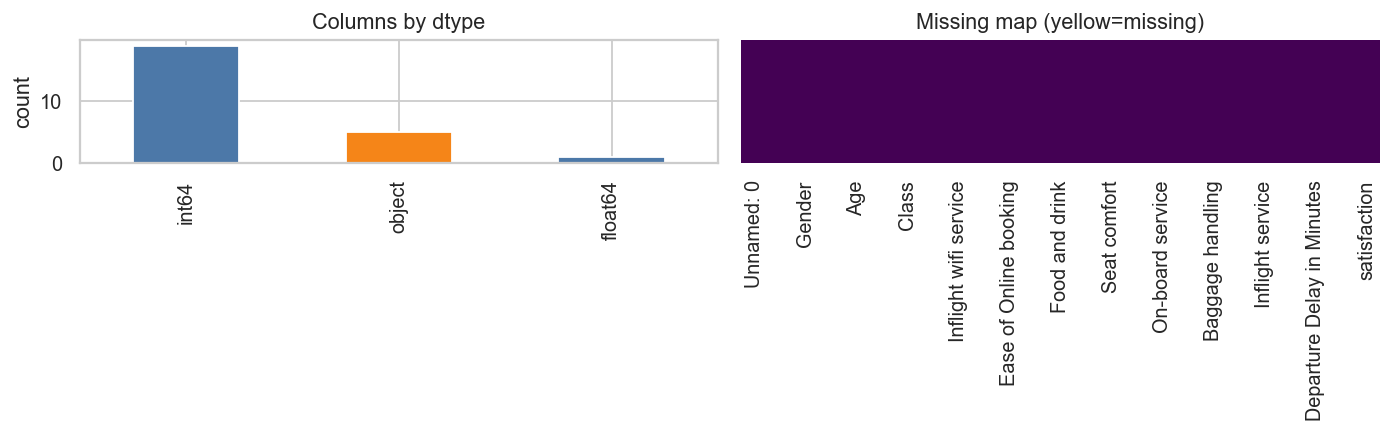

In [3]:
display(pd.DataFrame({'dtype':df.dtypes.astype(str),'unique':[df[c].nunique() for c in df.columns],'missing':df.isnull().sum().values,'missing_pct':(df.isnull().mean()*100).round(2)}, index=df.columns).style.background_gradient(subset=['missing'], cmap='Reds'))
df.info()
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
df.dtypes.value_counts().plot(kind='bar', ax=ax[0], color=['#4c78a8','#f58518']); ax[0].set_title('Columns by dtype'); ax[0].set_ylabel('count')
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax[1]); ax[1].set_title('Missing map (yellow=missing)')
plt.tight_layout(); plt.show()


## 5 Missing value analysis

,missing,pct
Arrival Delay in Minutes,310,0.300000


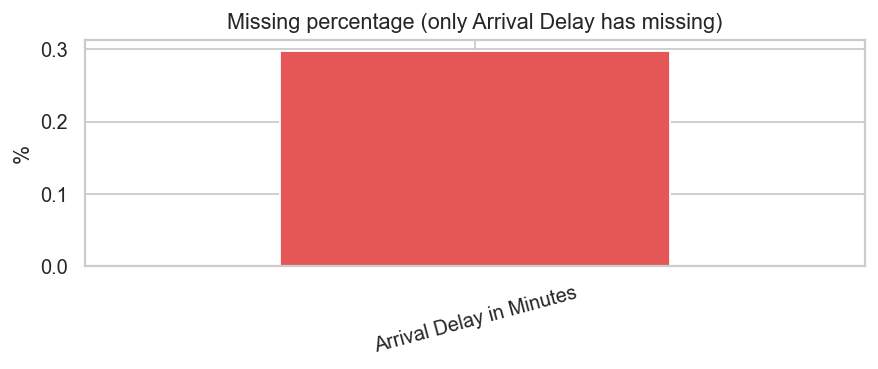

Conclusion: only Arrival Delay 310 (0.30%) - median impute later; 24 cols complete


In [4]:
miss = df.isnull().sum()
miss_pct = df.isnull().mean()*100
miss_df = pd.DataFrame({'missing':miss,'pct':miss_pct.round(2)}).query('missing>0')
display(miss_df.style.background_gradient(cmap='Oranges'))
fig,ax=plt.subplots(figsize=(7,3))
miss_pct[miss_pct>0].plot(kind='bar', color='#e45756', ax=ax)
ax.set_title('Missing percentage (only Arrival Delay has missing)'); ax.set_ylabel('%'); plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print('Conclusion: only Arrival Delay 310 (0.30%) - median impute later; 24 cols complete')


## 6 Duplicate analysis

duplicates: 0 (0.0000%)


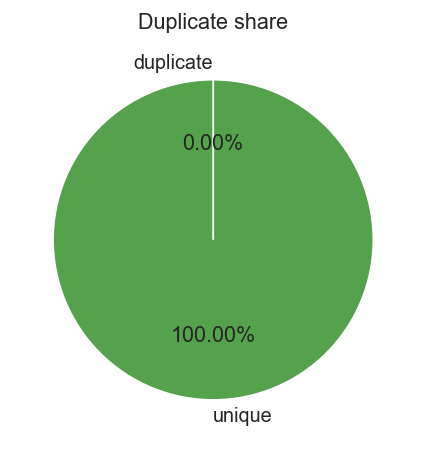

No removal in EDA


In [5]:
dups=df.duplicated().sum()
print(f"duplicates: {dups} ({dups/len(df)*100:.4f}%)")
labels=['unique','duplicate']; vals=[len(df)-dups, dups]
plt.figure(figsize=(4,4)); plt.pie(vals, labels=labels, autopct='%1.2f%%', colors=['#54a24b','#e45756'], startangle=90); plt.title('Duplicate share'); plt.show()
print('No removal in EDA')


## 7 Target variable

,count,pct
satisfaction,,
neutral or dissatisfied,58879,56.67
satisfied,45025,43.33


C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\962581363.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='satisfaction', data=df, palette=[COLORS[c] for c in vc.index], ax=ax[0])
C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\962581363.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=10)


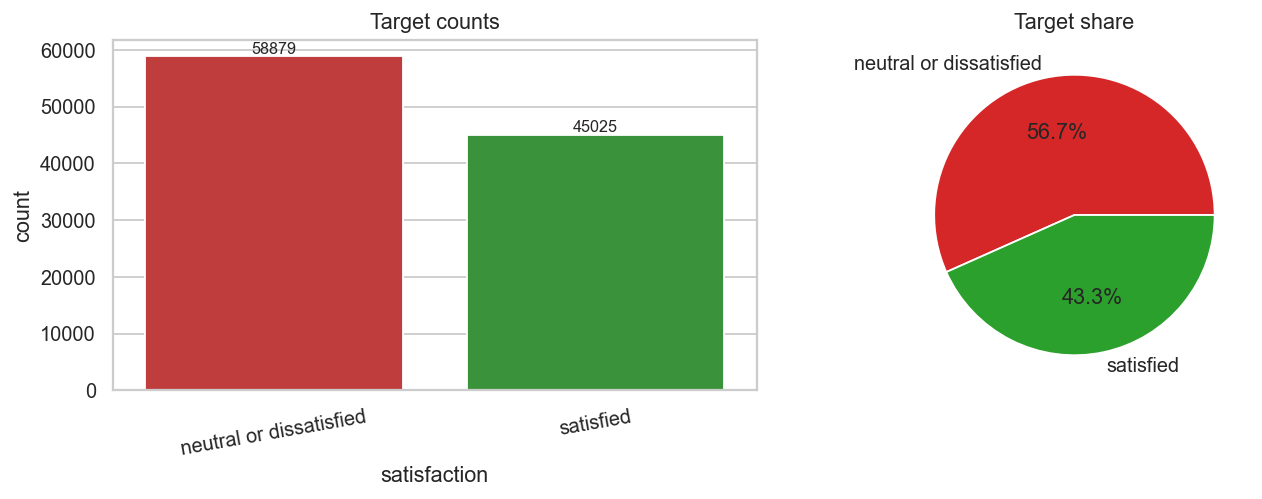

Mild imbalance 56.7 vs 43.3 - use stratified split


In [6]:
vc=df['satisfaction'].value_counts()
pct=df['satisfaction'].value_counts(normalize=True).mul(100).round(2)
display(pd.DataFrame({'count':vc,'pct':pct}))
fig,ax=plt.subplots(1,2,figsize=(11,4))
sns.countplot(x='satisfaction', data=df, palette=[COLORS[c] for c in vc.index], ax=ax[0])
ax[0].set_title('Target counts'); 
for p in ax[0].patches: ax[0].annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=10)
pct.plot(kind='pie', autopct='%1.1f%%', colors=[COLORS[c] for c in pct.index], ax=ax[1]); ax[1].set_title('Target share'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()
print('Mild imbalance 56.7 vs 43.3 - use stratified split')


## 8 Numerical feature analysis

,count,mean,std,min,25%,50%,75%,max
Age,103904.000000,39.379706,15.114964,7.000000,27.000000,40.000000,51.000000,85.000000
Flight Distance,103904.000000,1189.448375,997.147281,31.000000,414.000000,843.000000,1743.000000,4983.000000
Inflight wifi service,103904.000000,2.729683,1.327829,0.000000,2.000000,3.000000,4.000000,5.000000
Departure/Arrival time convenient,103904.000000,3.060296,1.525075,0.000000,2.000000,3.000000,4.000000,5.000000
Ease of Online booking,103904.000000,2.756901,1.398929,0.000000,2.000000,3.000000,4.000000,5.000000
Gate location,103904.000000,2.976883,1.277621,0.000000,2.000000,3.000000,4.000000,5.000000
Food and drink,103904.000000,3.202129,1.329533,0.000000,2.000000,3.000000,4.000000,5.000000
Online boarding,103904.000000,3.250375,1.349509,0.000000,2.000000,3.000000,4.000000,5.000000
Seat comfort,103904.000000,3.439396,1.319088,0.000000,2.000000,4.000000,5.000000,5.000000
Inflight entertainment,103904.000000,3.358158,1.332991,0.000000,2.000000,4.000000,4.000000,5.000000


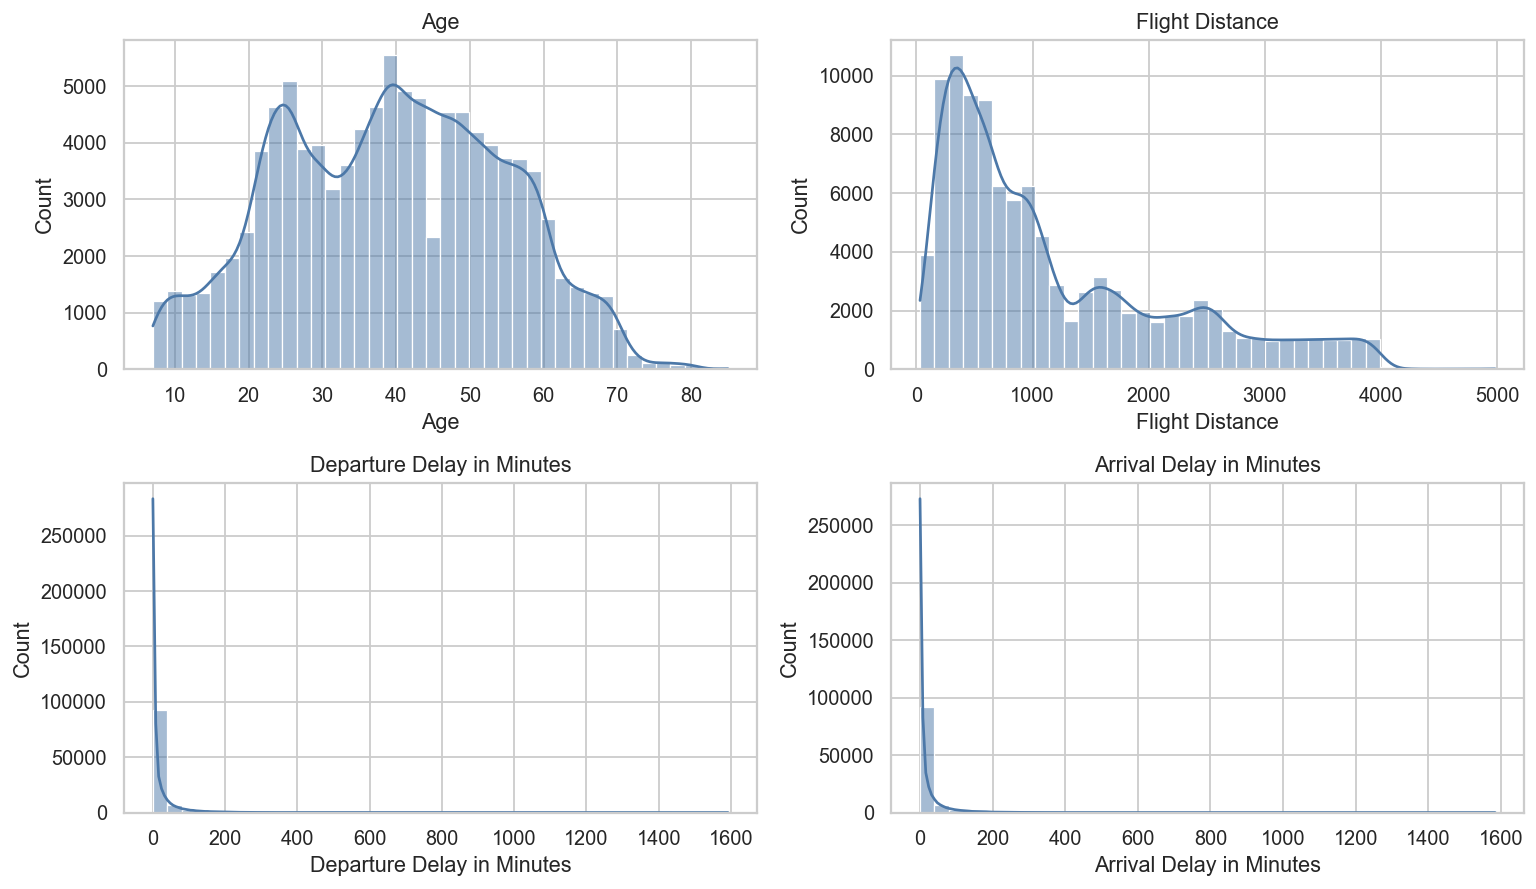

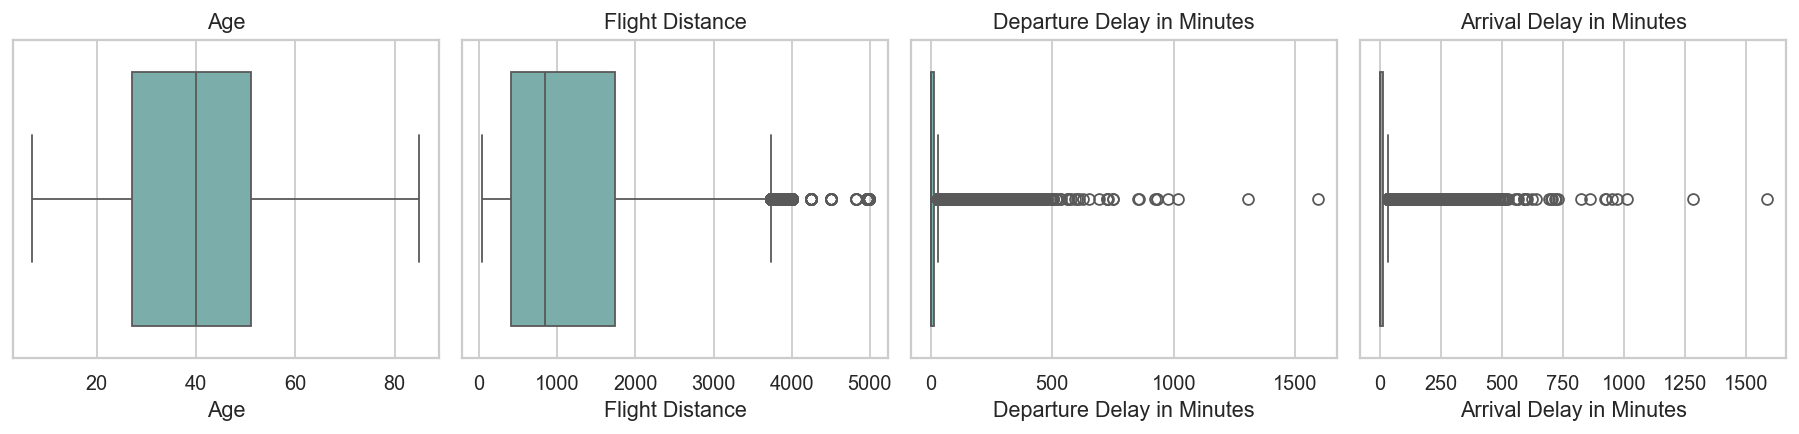

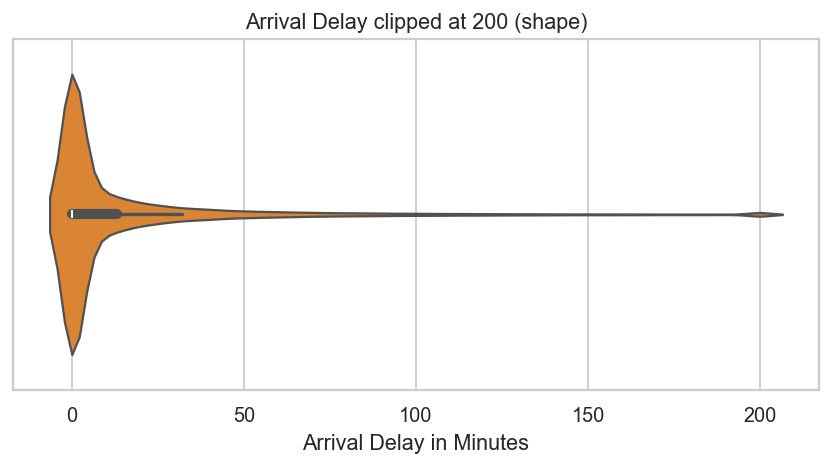

In [7]:
num_cols=[c for c in df.select_dtypes(include='number').columns if c not in ['Unnamed: 0','id']]
display(df[num_cols].describe().T.style.background_gradient(cmap='YlGnBu'))
# 2x2 grid of distributions
fig, axes=plt.subplots(2,2,figsize=(12,7))
for ax,c in zip(axes.flat, ['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']):
    sns.histplot(df[c].dropna(), bins=40, kde=True, color='#4c78a8', ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()
fig, axes=plt.subplots(1,4,figsize=(14,3.5))
for ax,c in zip(axes, ['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']):
    sns.boxplot(x=df[c].dropna(), color='#72b7b2', ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()
# violin for delays (log-like)
fig,ax=plt.subplots(figsize=(8,3.5))
sns.violinplot(x=df['Arrival Delay in Minutes'].dropna().clip(upper=200), color='#f58518'); ax.set_title('Arrival Delay clipped at 200 (shape)')
plt.show()


## 9 Categorical feature analysis

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\2841723299.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, order=order, palette='Set2', ax=ax)
C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\2841723299.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(c); ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\2841723299.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, order=order, palette='Set2', ax=ax)


C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\2841723299.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(c); ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\2841723299.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, order=order, palette='Set2', ax=ax)
C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\2841723299.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(c); ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\2841723299.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\2841723299.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(c); ax.set_xticklabels(ax.get_xticklabels(), rotation=15)


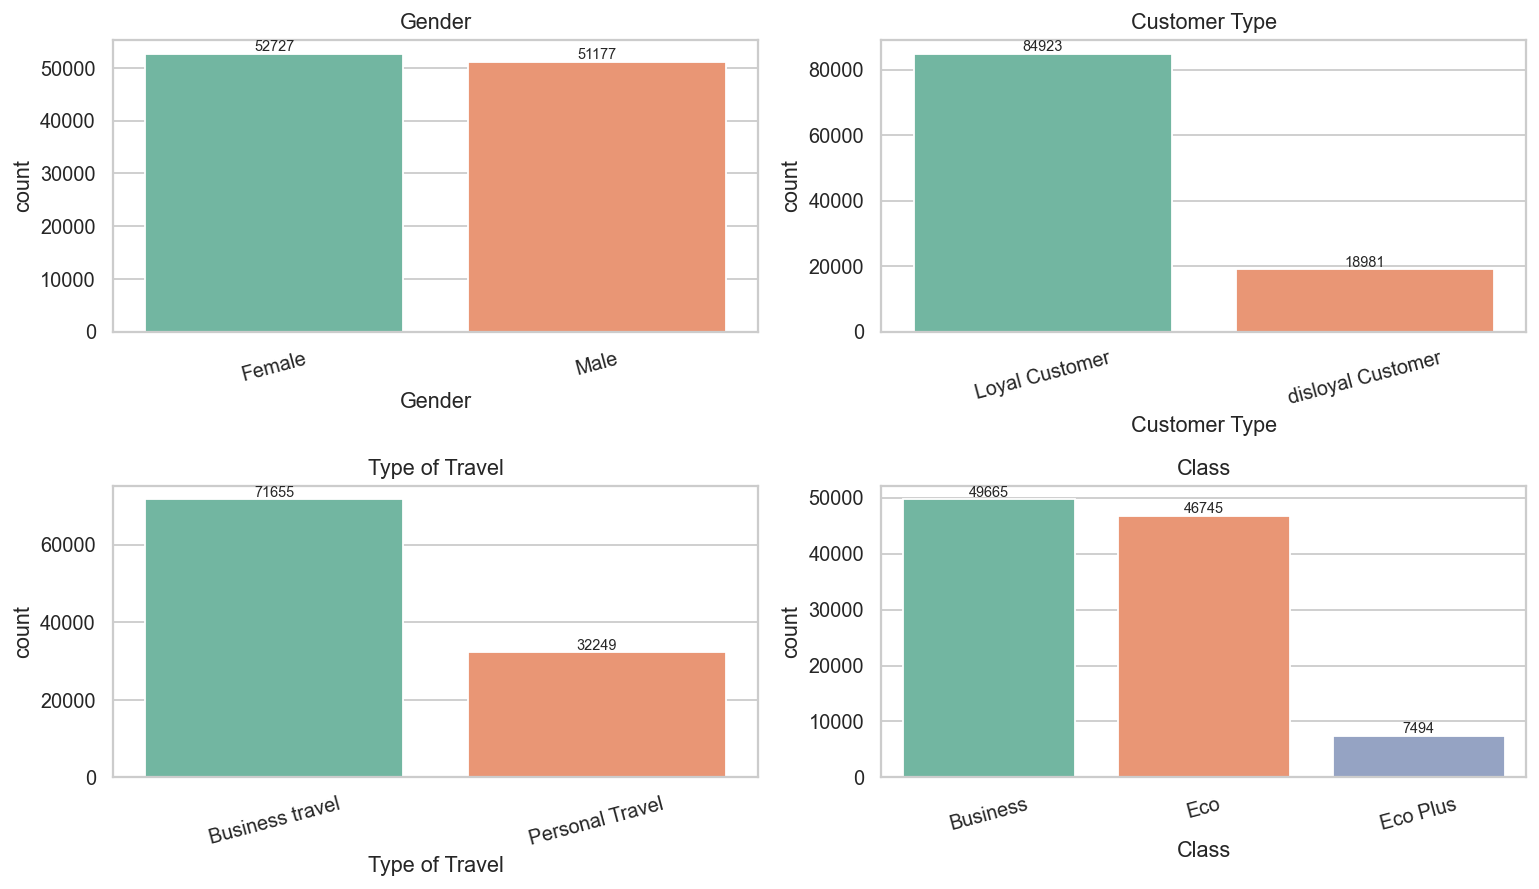

,count,pct
Gender,,
Female,52727,50.7
Male,51177,49.3


,count,pct
Customer Type,,
Loyal Customer,84923,81.7
disloyal Customer,18981,18.3


,count,pct
Type of Travel,,
Business travel,71655,69.0
Personal Travel,32249,31.0


,count,pct
Class,,
Business,49665,47.8
Eco,46745,45.0
Eco Plus,7494,7.2


In [8]:
cat_cols=['Gender','Customer Type','Type of Travel','Class']
fig, axes=plt.subplots(2,2,figsize=(12,7))
for ax,c in zip(axes.flat, cat_cols):
    order=df[c].value_counts().index
    sns.countplot(x=c, data=df, order=order, palette='Set2', ax=ax)
    ax.set_title(c); ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
    for p in ax.patches: ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()
for c in cat_cols:
    display(pd.DataFrame({'count':df[c].value_counts(),'pct':df[c].value_counts(normalize=True).mul(100).round(1)}))


## 10 Service rating analysis

,count,mean,std,min,25%,50%,75%,max
Inflight wifi service,103904.000000,2.729683,1.327829,0.000000,2.000000,3.000000,4.000000,5.000000
Departure/Arrival time convenient,103904.000000,3.060296,1.525075,0.000000,2.000000,3.000000,4.000000,5.000000
Ease of Online booking,103904.000000,2.756901,1.398929,0.000000,2.000000,3.000000,4.000000,5.000000
Gate location,103904.000000,2.976883,1.277621,0.000000,2.000000,3.000000,4.000000,5.000000
Food and drink,103904.000000,3.202129,1.329533,0.000000,2.000000,3.000000,4.000000,5.000000
Online boarding,103904.000000,3.250375,1.349509,0.000000,2.000000,3.000000,4.000000,5.000000
Seat comfort,103904.000000,3.439396,1.319088,0.000000,2.000000,4.000000,5.000000,5.000000
Inflight entertainment,103904.000000,3.358158,1.332991,0.000000,2.000000,4.000000,4.000000,5.000000
On-board service,103904.000000,3.382363,1.288354,0.000000,2.000000,4.000000,4.000000,5.000000
Leg room service,103904.000000,3.351055,1.315605,0.000000,2.000000,4.000000,4.000000,5.000000


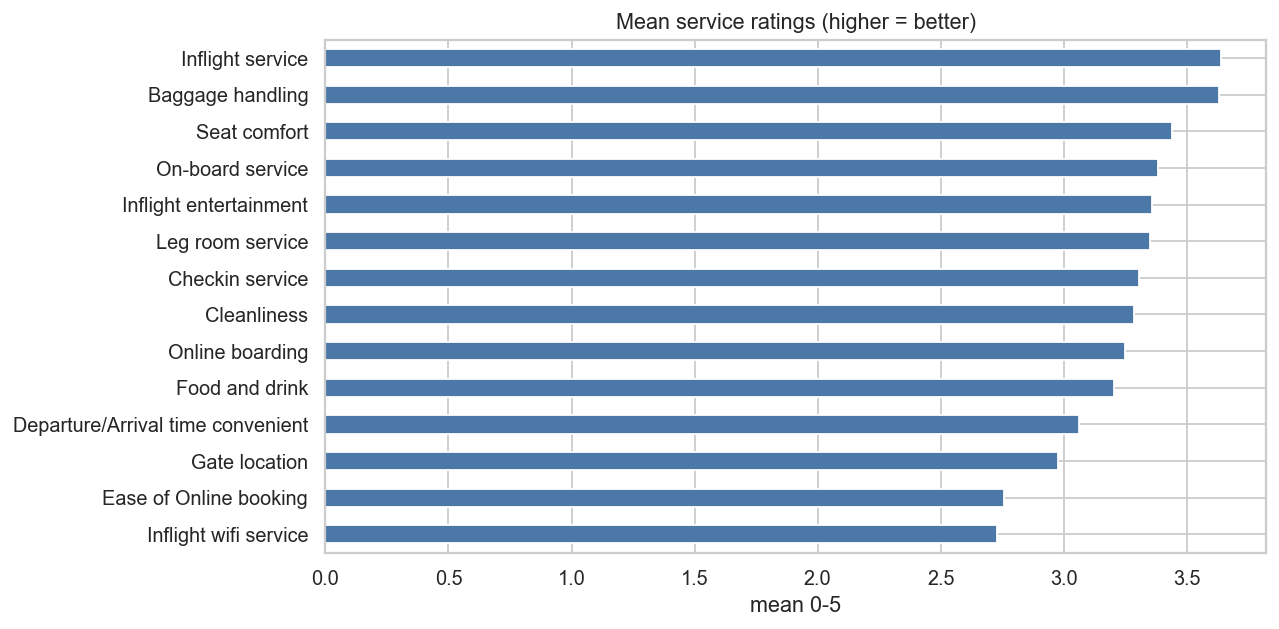

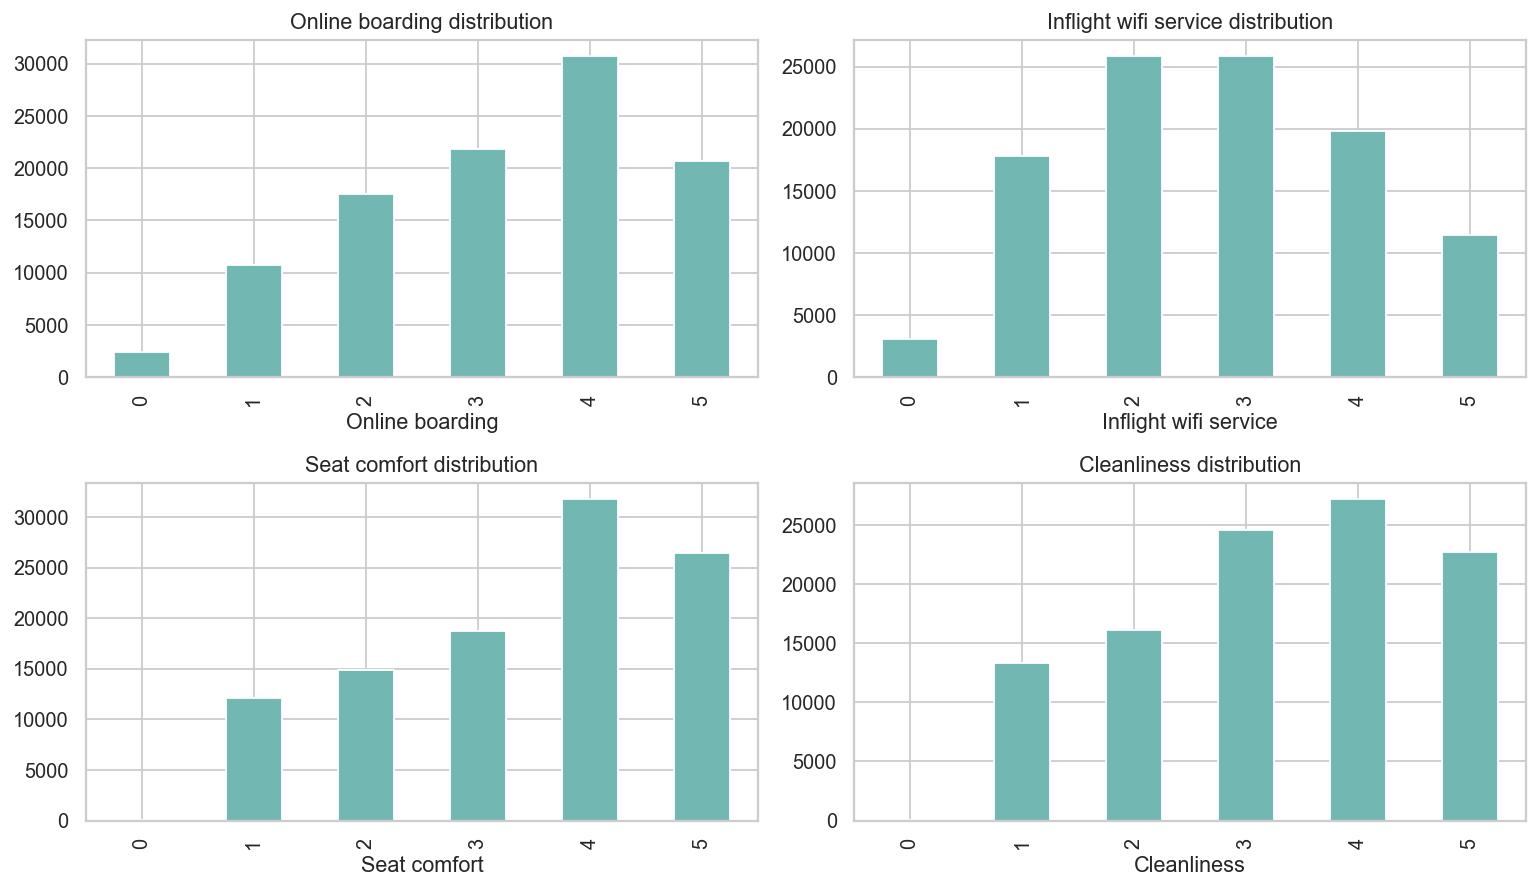

In [9]:
rating_cols=['Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking','Gate location','Food and drink','Online boarding','Seat comfort','Inflight entertainment','On-board service','Leg room service','Baggage handling','Checkin service','Inflight service','Cleanliness']
display(df[rating_cols].describe().T.style.background_gradient(cmap='PuBu'))
fig,ax=plt.subplots(figsize=(10,5))
df[rating_cols].mean().sort_values().plot(kind='barh', color='#4c78a8', ax=ax); ax.set_title('Mean service ratings (higher = better)'); ax.set_xlabel('mean 0-5'); plt.tight_layout(); plt.show()
# stacked dist for top 4
fig,axes=plt.subplots(2,2,figsize=(12,7))
for ax,c in zip(axes.flat, ['Online boarding','Inflight wifi service','Seat comfort','Cleanliness']):
    df[c].value_counts().sort_index().plot(kind='bar', color='#72b7b2', ax=ax); ax.set_title(c+' distribution')
plt.tight_layout(); plt.show()


## 11 Outlier analysis (IQR + box)

Age: Q1=27.0 Q3=51.0 IQR=24.0 outliers=0 (0.00%)
Flight Distance: Q1=414.0 Q3=1743.0 IQR=1329.0 outliers=2291 (2.20%)
Departure Delay in Minutes: Q1=0.0 Q3=12.0 IQR=12.0 outliers=14529 (13.98%)
Arrival Delay in Minutes: Q1=0.0 Q3=13.0 IQR=13.0 outliers=13954 (13.43%)


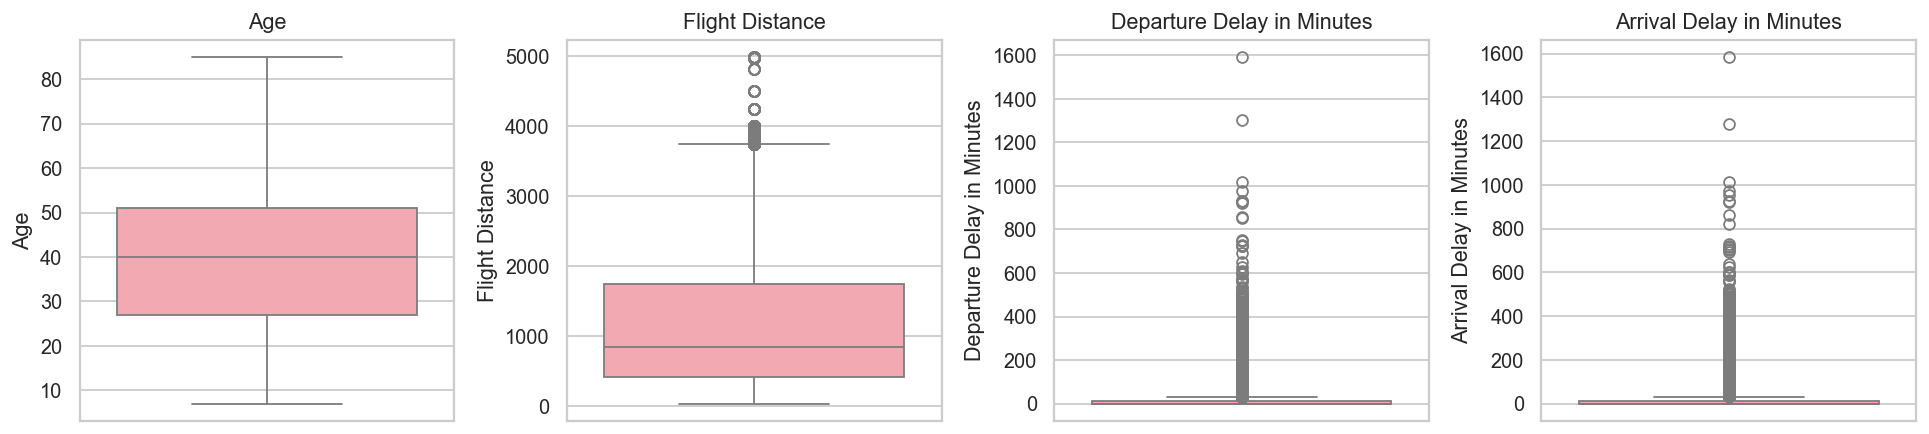

Delays have long-tail outliers but are genuine travel delays - do not drop


In [10]:
for c in ['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']:
    q1,q3=df[c].quantile([0.25,0.75]); iqr=q3-q1; out=((df[c]<q1-1.5*iqr)|(df[c]>q3+1.5*iqr)).sum()
    print(f"{c}: Q1={q1:.1f} Q3={q3:.1f} IQR={iqr:.1f} outliers={out} ({out/len(df)*100:.2f}%)")
fig,axes=plt.subplots(1,4,figsize=(15,3.5))
for ax,c in zip(axes, ['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']):
    sns.boxplot(y=df[c].dropna(), color='#ff9da7', ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()
print('Delays have long-tail outliers but are genuine travel delays - do not drop')


## 12 Correlation analysis

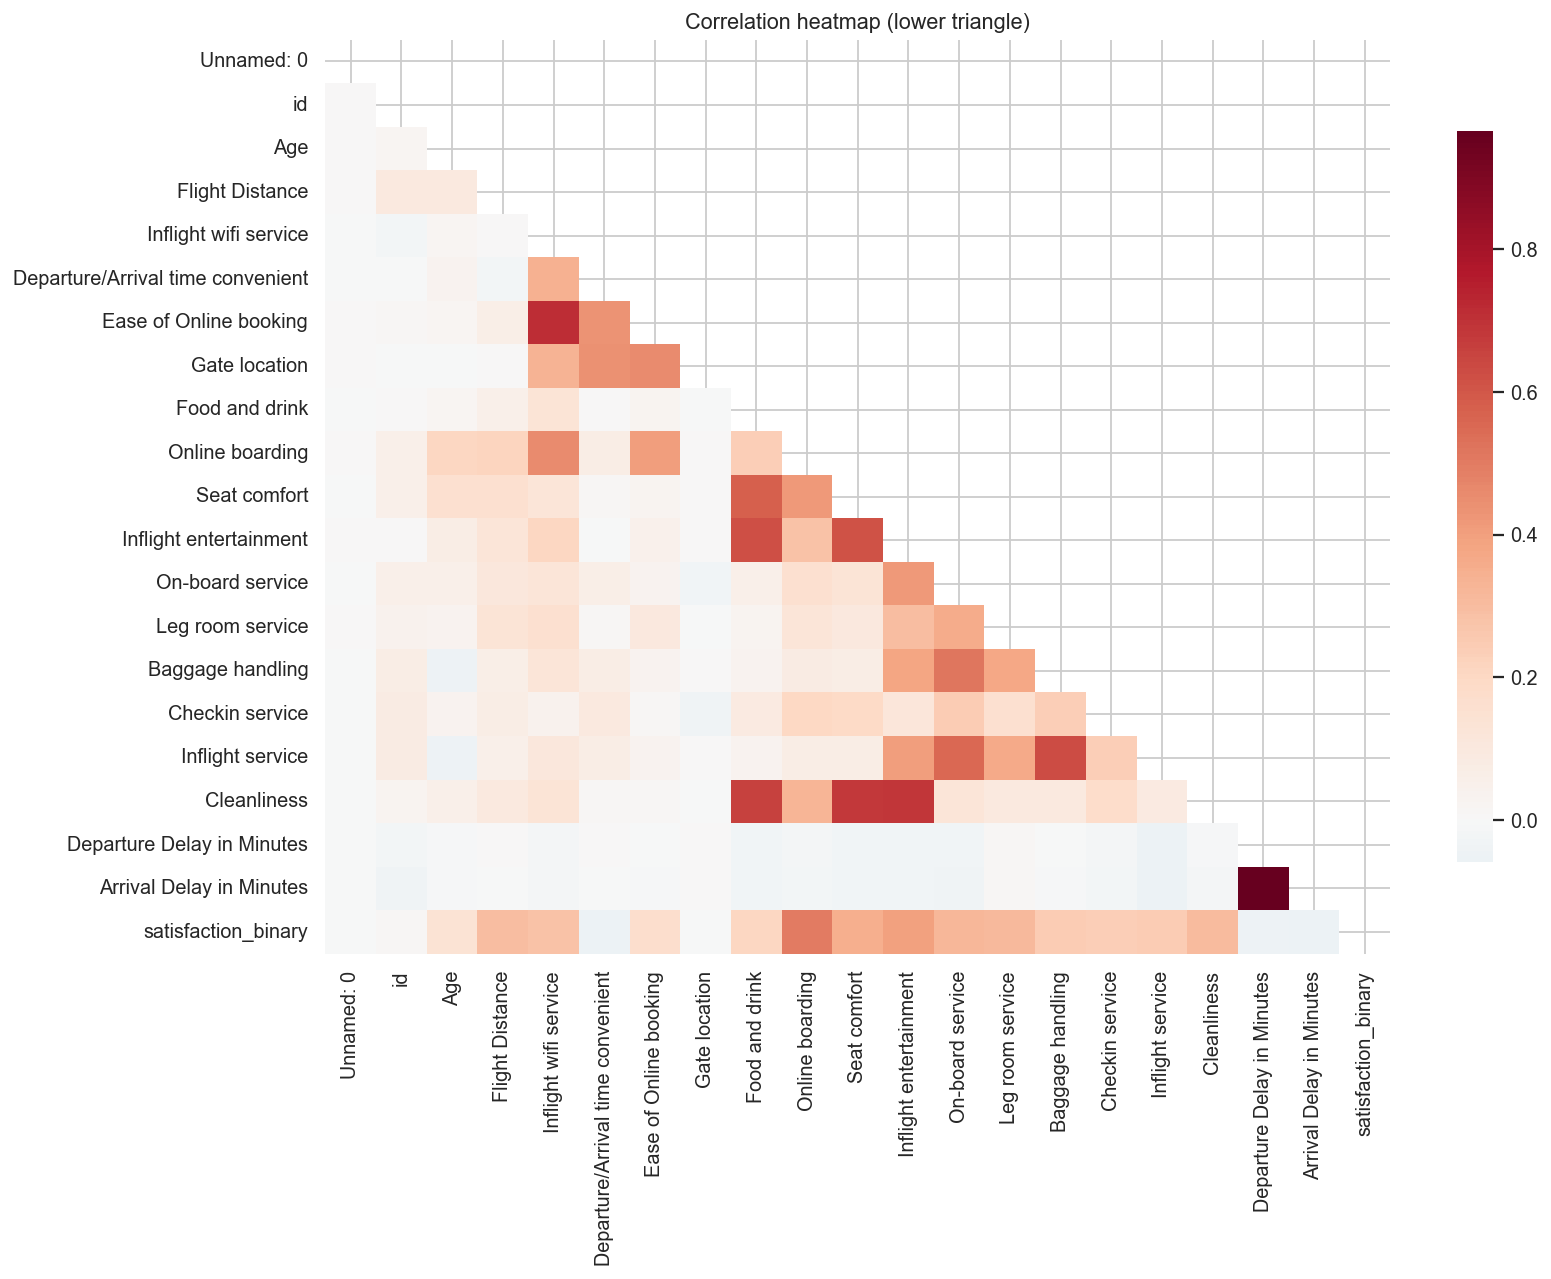

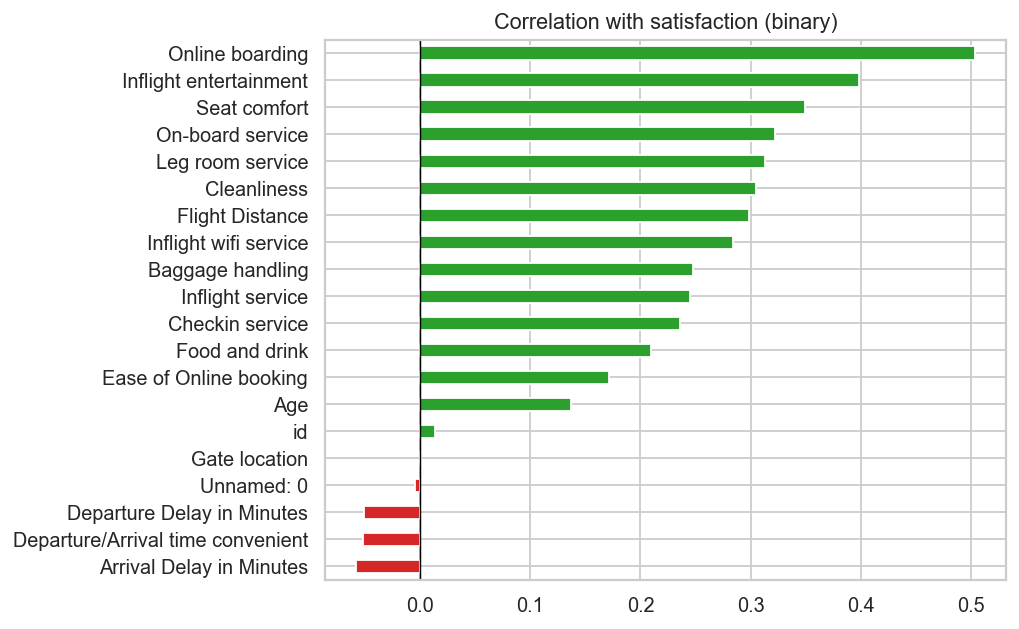

Arrival Delay in Minutes            -0.058
Departure/Arrival time convenient   -0.052
Departure Delay in Minutes          -0.050
Unnamed: 0                          -0.005
Gate location                        0.001
id                                   0.014
Age                                  0.137
Ease of Online booking               0.172
Food and drink                       0.210
Checkin service                      0.236
Inflight service                     0.245
Baggage handling                     0.248
Inflight wifi service                0.284
Flight Distance                      0.299
Cleanliness                          0.305
Leg room service                     0.313
On-board service                     0.322
Seat comfort                         0.349
Inflight entertainment               0.398
Online boarding                      0.504


In [11]:
tmp=df.copy()
tmp['satisfaction_binary']=tmp['satisfaction'].map({'neutral or dissatisfied':0,'satisfied':1})
corr=tmp.select_dtypes(include='number').corr(numeric_only=True)
plt.figure(figsize=(13,10)); mask=np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False, cbar_kws={'shrink':0.8}); plt.title('Correlation heatmap (lower triangle)'); plt.tight_layout(); plt.show()
# bar of corr with target
target_corr=corr['satisfaction_binary'].drop('satisfaction_binary').sort_values()
fig,ax=plt.subplots(figsize=(8,5))
colors=['#d62728' if v<0 else '#2ca02c' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, ax=ax); ax.set_title('Correlation with satisfaction (binary)'); ax.axvline(0,color='black',linewidth=0.8); plt.tight_layout(); plt.show()
print(target_corr.round(3).to_string())


## 13 Feature vs Target

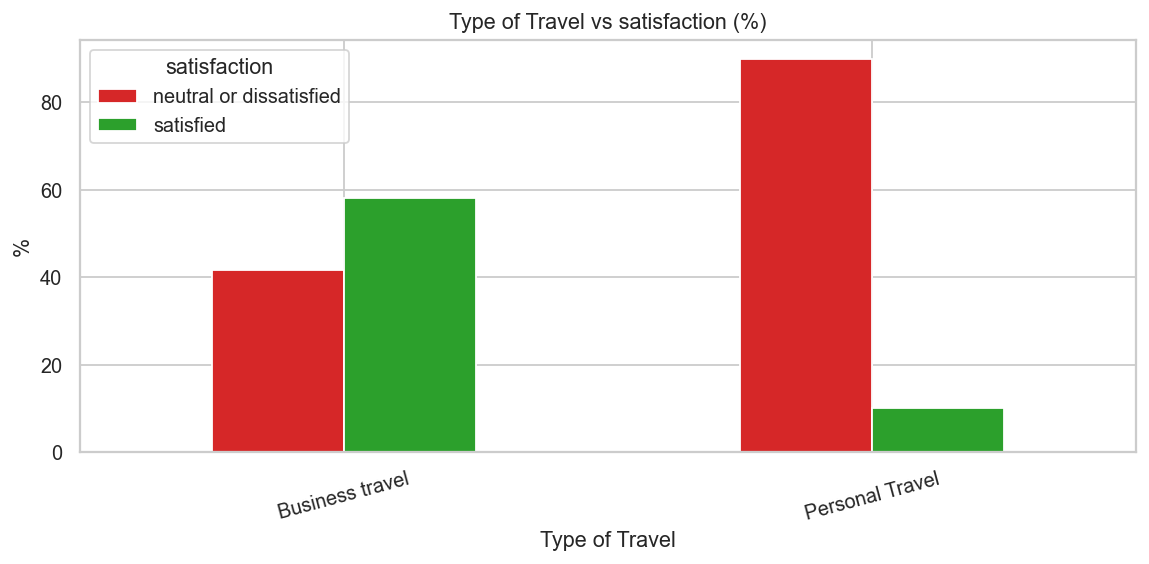

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,41.700000,58.300000
Personal Travel,89.800000,10.200000


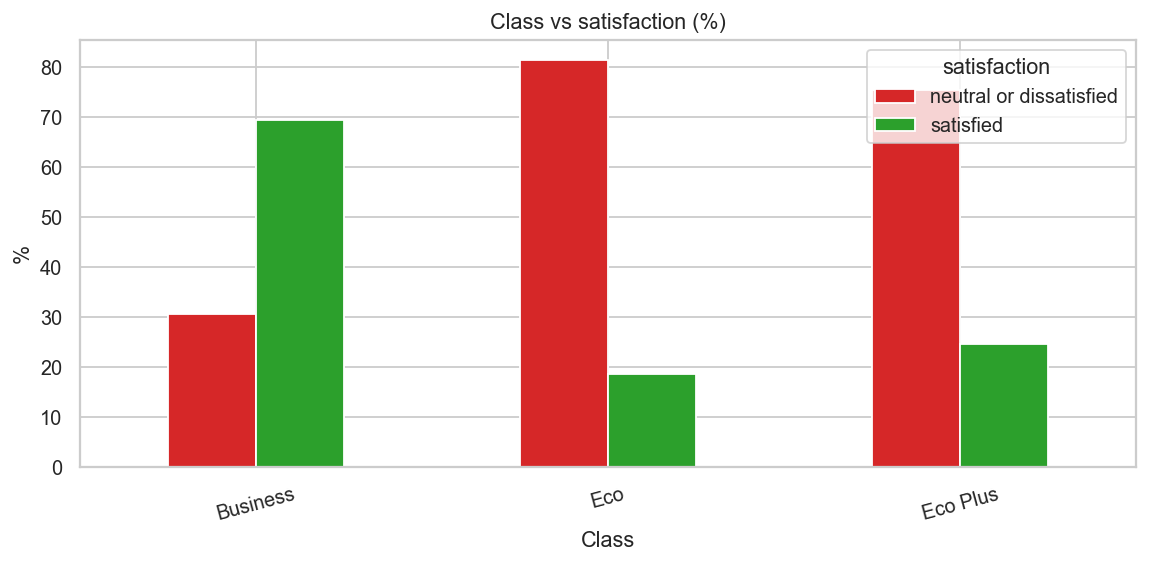

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.600000,69.400000
Eco,81.400000,18.600000
Eco Plus,75.400000,24.600000


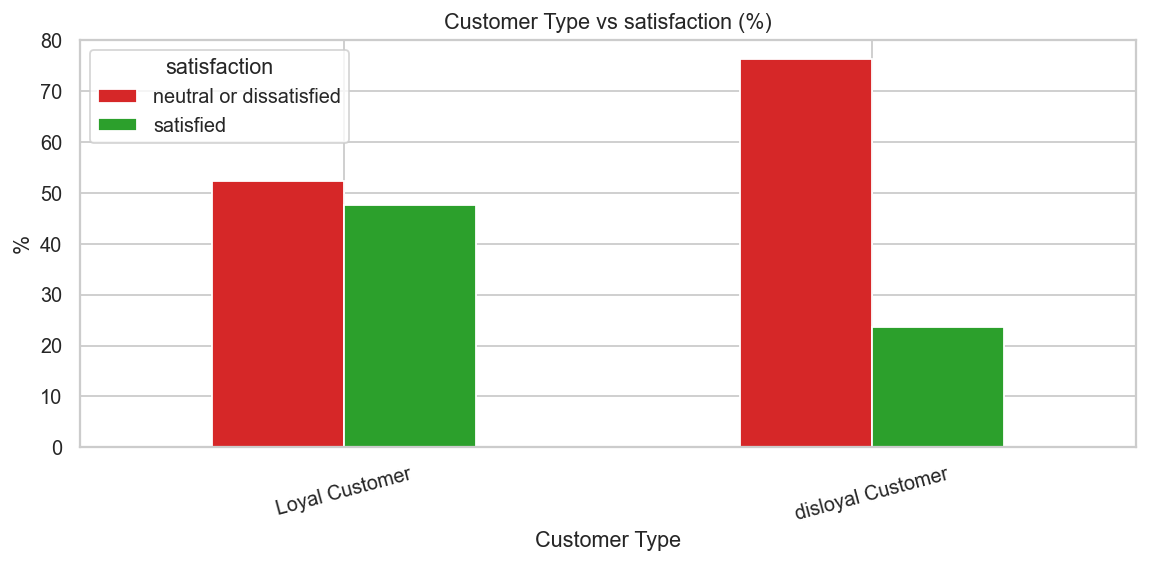

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,52.300000,47.700000
disloyal Customer,76.300000,23.700000


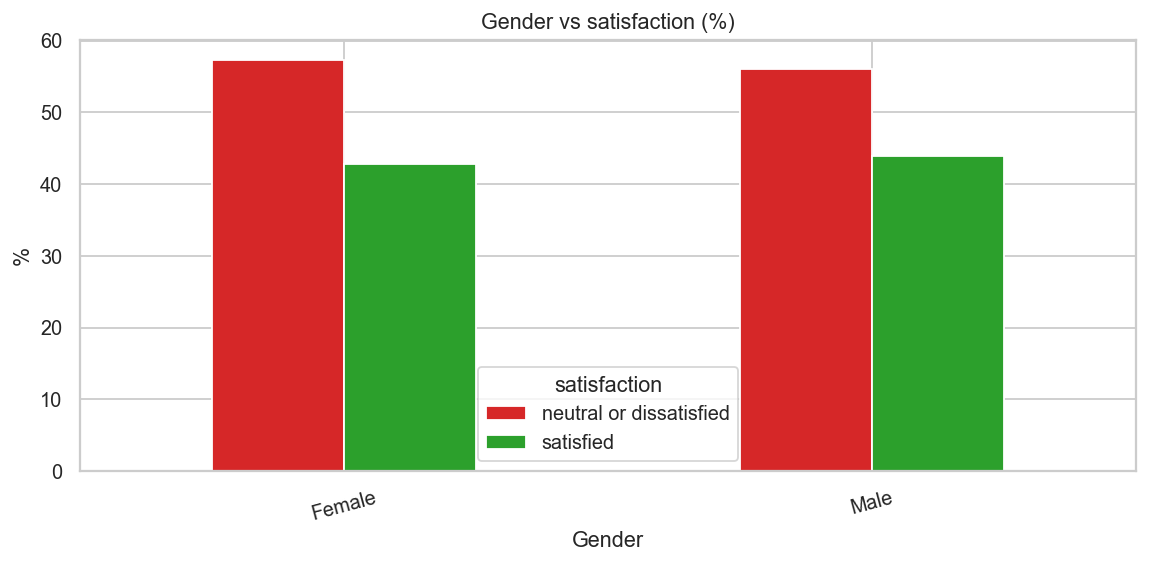

satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,57.300000,42.700000
Male,56.100000,43.900000


C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


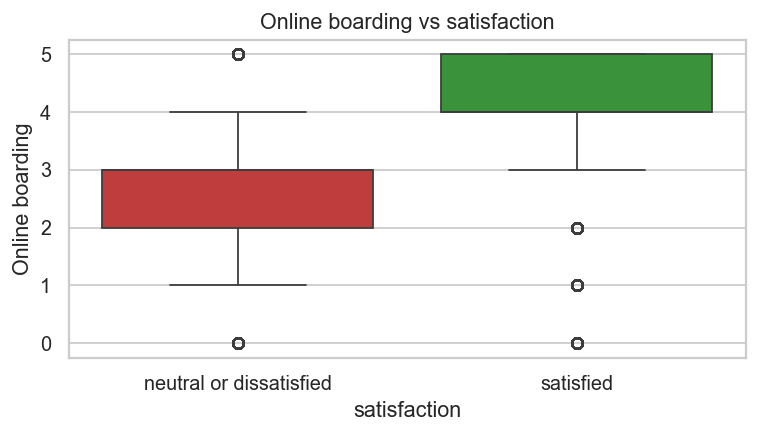

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


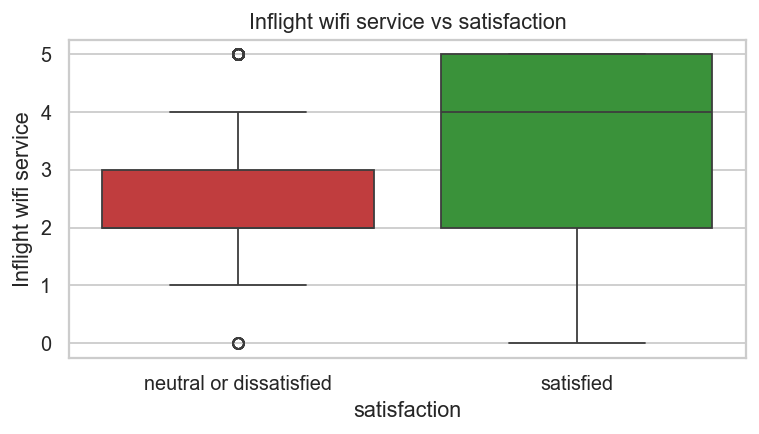

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


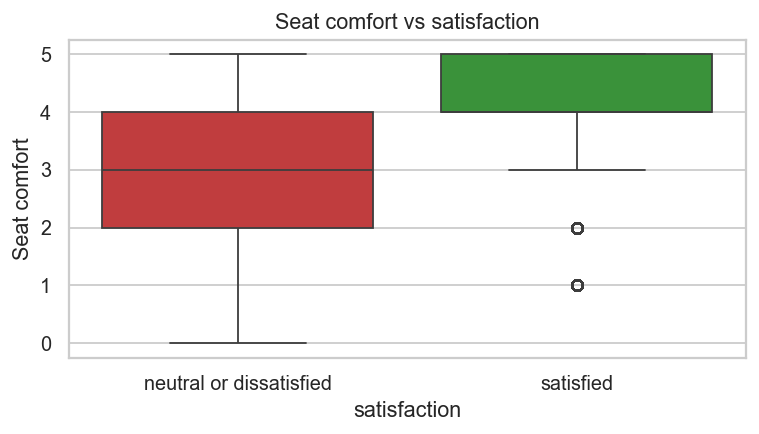

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


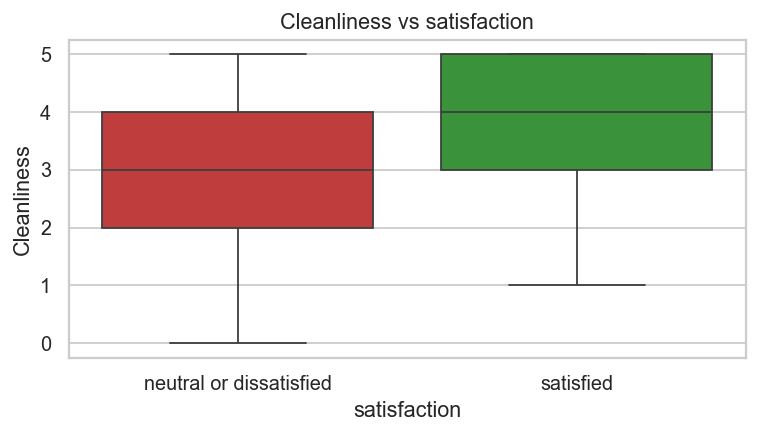

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


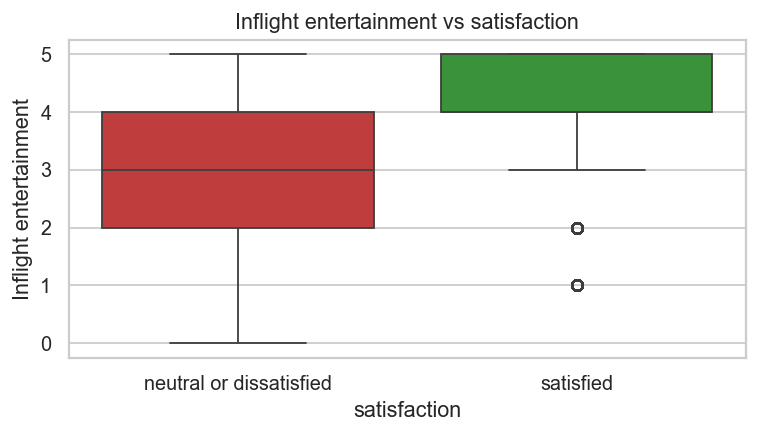

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


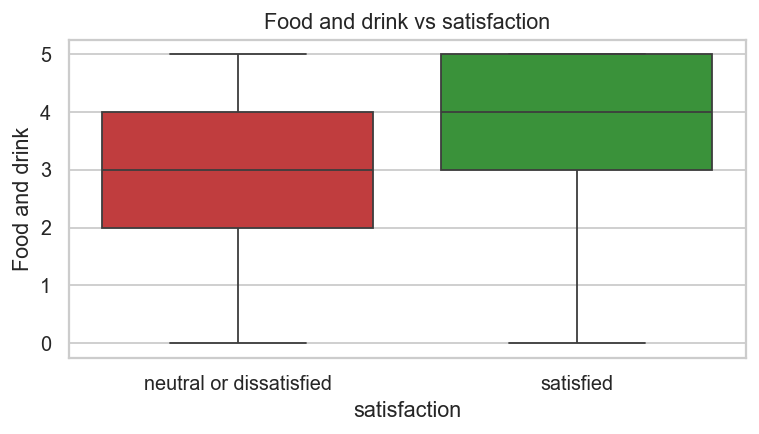

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


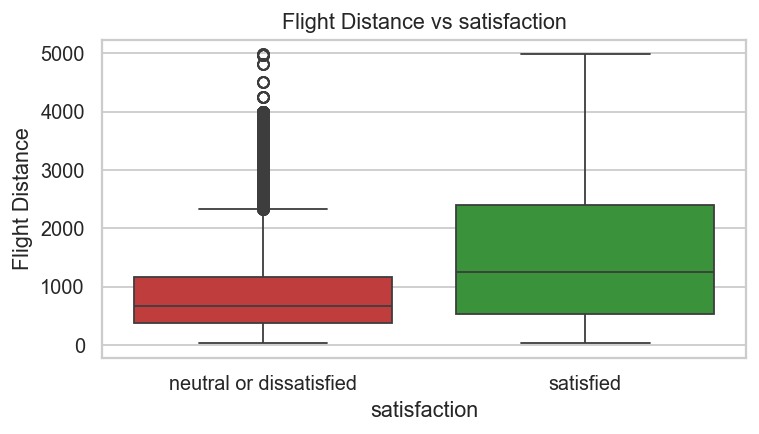

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


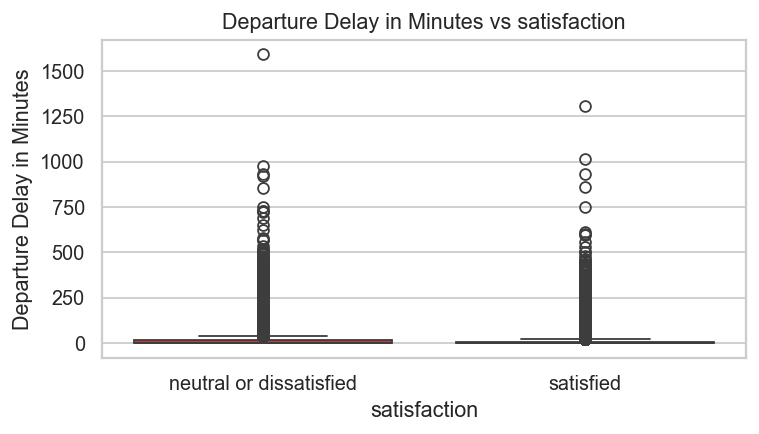

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


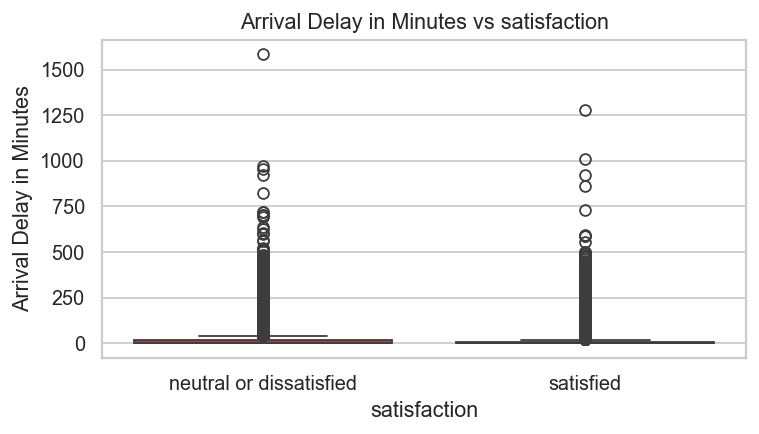

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()


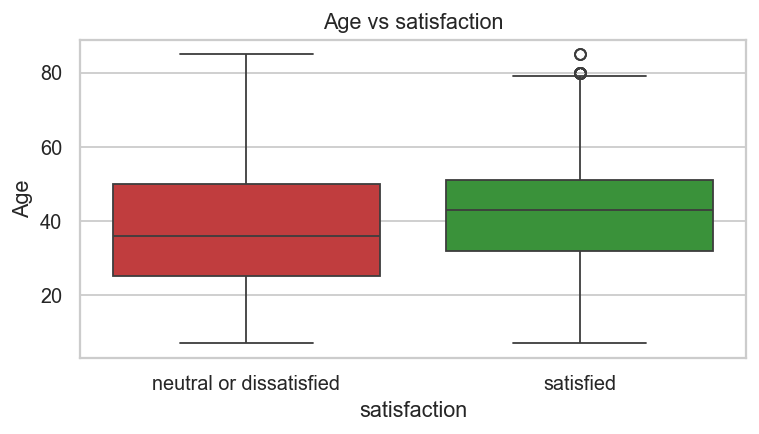

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=df[c].clip(upper=100), data=df, palette=COLORS); plt.title(c+' clipped at 100 vs satisfaction'); plt.tight_layout(); plt.show()


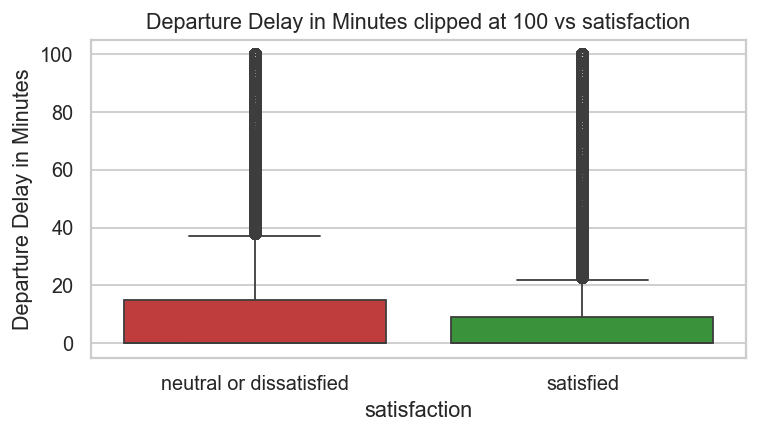

C:\Users\DIXIT\AppData\Local\Temp\ipykernel_15776\1510935792.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='satisfaction', y=df[c].clip(upper=100), data=df, palette=COLORS); plt.title(c+' clipped at 100 vs satisfaction'); plt.tight_layout(); plt.show()


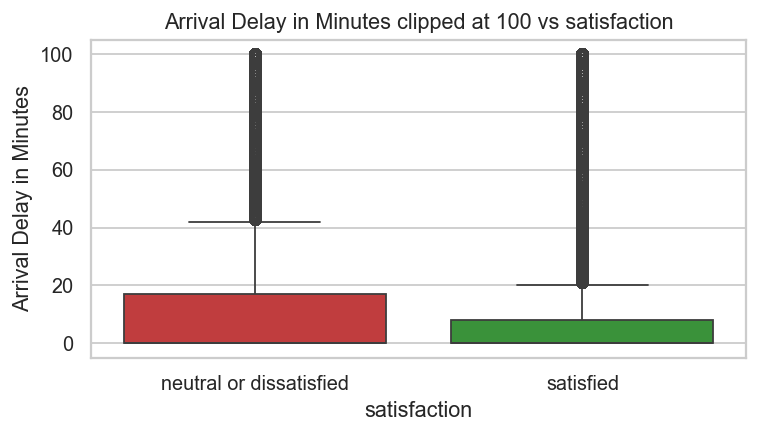

In [12]:
for c in ['Type of Travel','Class','Customer Type','Gender']:
    ct=pd.crosstab(df[c], df['satisfaction'], normalize='index')*100
    ct.plot(kind='bar', color=[COLORS['neutral or dissatisfied'], COLORS['satisfied']]); plt.title(c+' vs satisfaction (%)'); plt.ylabel('%'); plt.xticks(rotation=15); plt.legend(title='satisfaction'); plt.tight_layout(); plt.show()
    display(ct.round(1).style.background_gradient(cmap='Greens'))
# numeric vs target
for c in ['Online boarding','Inflight wifi service','Seat comfort','Cleanliness','Inflight entertainment','Food and drink','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes','Age']:
    plt.figure(figsize=(6,3.5))
    sns.boxplot(x='satisfaction', y=c, data=df, palette=COLORS); plt.title(c+' vs satisfaction'); plt.tight_layout(); plt.show()
# delay clip view
for c in ['Departure Delay in Minutes','Arrival Delay in Minutes']:
    plt.figure(figsize=(6,3.5))
    sns.boxplot(x='satisfaction', y=df[c].clip(upper=100), data=df, palette=COLORS); plt.title(c+' clipped at 100 vs satisfaction'); plt.tight_layout(); plt.show()


## 14 Key EDA Findings
- Train 103904x25 Test 25976x25 same schema
- 1 missing col only Arrival Delay 0.30%
- 0 duplicates
- Target mildly imbalanced 56.7/43.3
- Business travel 69% and Business class 48% dominate satisfied group
- Delays right-skewed median 0 max 1584 with genuine long-tail outliers
- Service ratings means 2.8-3.6, most discriminative: Online boarding, entertainment, seat comfort, wifi
- Flight Distance and Age weakly correlated with target

## 15 Recommended Preprocessing Strategy (not implemented here)
- Median impute Arrival Delay (robust)
- Drop Unnamed:0, id
- drop_duplicates
- OneHot Gender/Customer Type/Type of Travel/Class (handle_unknown=ignore)
- StandardScaler numeric via ColumnTransformer+Pipeline fitted on train only
- Keep outliers, tree models robust
- Map target satisfied->1
- Stratified split, no leakage from test

## 16 Conclusion
Data is clean except tiny missing and skewed delays. Satisfaction driven by travel type/class and service quality. Next step: implement recommended preprocessing in src/preprocessing.py without touching raw CSVs.